# Clusters vs Pathology Intensity

Assesses whether microglia cluster proportions (hard KMeans, k=4) trend with NIA-AA AD pathology intensity and correlate with individual pathology scores, across all scans (AD + 100+).

In [1]:
import os
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy import stats
from analysis_utils import get_morphology_results_from_folder, show_cluster_representatives

## Load Data

In [2]:
df, X_scaled = get_morphology_results_from_folder(
    folder_path=r"C:\Users\chris\Desktop\University\Thesis\PipelineResults\Many_Patients",
    remove_outlier_sizes=False,
    remove_edges=True,
)
scan_data_root = r"C:\Users\chris\Desktop\University\Thesis\ScanData\All_scans_tiled"

Number of cells in analysis 1679362
Removed 507259 border-clipped cells (1679362 -> 1172103)


## t-SNE Embedding

In [3]:
read_from_csv = True

if read_from_csv:
    print('loading from csv')
    df_loaded = pd.read_csv("tsne_enriched_results_4.csv")
    X_tsne_fast = df_loaded[["tsne_1", "tsne_2", "tsne_3", "tsne_4"]].to_numpy()
else:
    from analysis_utils import get_tsne_subsampled_and_projected
    X_tsne_fast = get_tsne_subsampled_and_projected(X_scaled, tsne_subsample=30000, n_components=4)

loading from csv


## KMeans Clustering (Hard, k=4)

Loaded KMeans labels from: kmeans_tsne_clusters_k4.csv


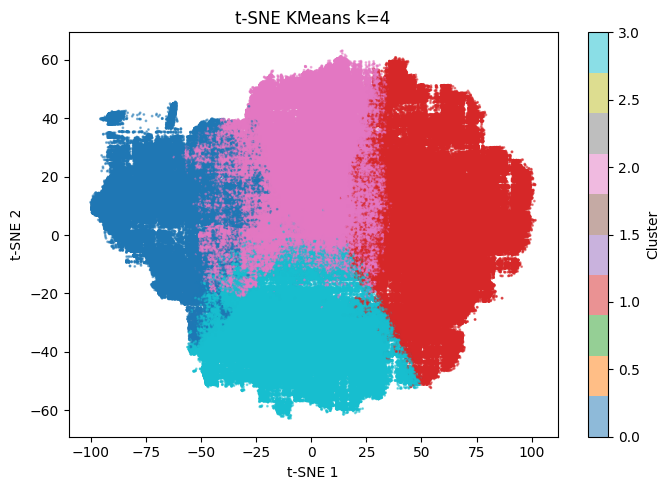

In [4]:
from sklearn.cluster import KMeans

n_clusters = 4
kmeans_cluster_path = f"kmeans_tsne_clusters_k{n_clusters}.csv"
read_kmeans_from_csv = True

if read_kmeans_from_csv:
    kmeans_loaded = pd.read_csv(kmeans_cluster_path)
    tsne_fast_cluster_labels = kmeans_loaded["hard_cluster"].to_numpy(dtype=int)
    print(f"Loaded KMeans labels from: {kmeans_cluster_path}")
else:
    tsne_fast_kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=42)
    tsne_fast_cluster_labels = tsne_fast_kmeans.fit_predict(X_tsne_fast)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_tsne_fast[:, 0], X_tsne_fast[:, 1], c=tsne_fast_cluster_labels, cmap='tab10', s=1, alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title(f't-SNE KMeans k={n_clusters}')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.tight_layout(); plt.show()

In [5]:
all_morphology_features = [
    'skeleton_length', 'num_junctions', 'num_components', 'num_end_nodes', 'num_start_nodes',
    'total_nodes', 'end_to_start_ratio', 'soma_area', 'soma_perimeter', 'soma_circularity',
    'cell_area', 'cell_perimeter', 'cell_convex_hull_area', 'cell_convex_hull_perimeter',
    'cell_solidity', 'cell_convexity', 'cell_circularity', 'cell_convex_circularity',
    'branch_area', 'branch_perimeter', 'sholl_min_radius', 'sholl_peak_radius',
    'sholl_max_radius', 'sholl_peak', 'sholl_sum',
]

## Diagnosis Groups & Extra Variables

In [6]:
scan_str = df["scan_name"].astype(str)
ad_mask = (
    scan_str.str.contains("ad", case=False, regex=False, na=False)
    | scan_str.str.contains("2002-061", case=False, regex=False, na=False)
    | scan_str.str.contains("2006-060", case=False, regex=False, na=False)
)

df_analysis = df.copy()
df_analysis["diagnosis_group"] = np.where(ad_mask, "AD", "100+")

scan_group_counts = (
    df_analysis[["scan_name", "diagnosis_group"]]
    .drop_duplicates("scan_name")
    .groupby("diagnosis_group")["scan_name"]
    .nunique()
    .sort_index()
)
print("Number of scans per diagnosis group:")
print(scan_group_counts.to_string())

Number of scans per diagnosis group:
diagnosis_group
100+    84
AD       7


In [7]:
from statistical_tests import aggregate_scan_level_morphology_df

cohort_df = pd.read_csv("cohort_extra_variables.csv")
df_analysis["scan_name"] = df_analysis["scan_name"].astype(str)
cohort_df["NBB"] = cohort_df["NBB"].astype(str).str.strip()

nbb_values = sorted(cohort_df["NBB"].dropna().unique().tolist(), key=len, reverse=True)
pattern = "|".join(re.escape(v) for v in nbb_values)
df_analysis["NBB_match"] = df_analysis["scan_name"].str.extract(f"({pattern})", expand=False)

cohort_unique = cohort_df.drop_duplicates(subset=["NBB"])
df_analysis = df_analysis.merge(
    cohort_unique, left_on="NBB_match", right_on="NBB", how="left"
).drop(columns=["NBB_match"])

scan_features = [
    "Group", "Sex", "Age_at_death",
    "Thal_AÎ²_stage", "Braak_NFT_stage", "CERAD_score",
    "AÎ² load_total", "AÎ²40_load", "AÎ²42_load",
    "AT8_load", "pTau217_load", "GT38_load",
]

df_summary_per_scan = aggregate_scan_level_morphology_df(
    df_analysis, morphology_features=all_morphology_features, scan_features=scan_features
)
print(df_summary_per_scan.shape)

(91, 35)


In [10]:
def _max_stage_from_text(value):
    if pd.isna(value): return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)): return float(value)
    matches = re.findall(r"\d+(?:\.\d+)?", str(value))
    return max(float(m) for m in matches) if matches else np.nan

def _thal_to_a_score(v):
    if pd.isna(v): return np.nan
    if v <= 0: return 'A0'
    if v <= 2: return 'A1'
    if v <= 3: return 'A2'
    return 'A3'

def _braak_to_b_score(v):
    if pd.isna(v): return np.nan
    if v <= 0: return 'B0'
    if v <= 2: return 'B1'
    if v <= 4: return 'B2'
    return 'B3'

def _cerad_to_c_score(v):
    if pd.isna(v): return np.nan
    if v <= 0: return 'C0'
    if v <= 1: return 'C1'
    if v <= 2: return 'C2'
    return 'C3'

def _nia_aa_ad_intensity(a, b, c):
    if pd.isna(a) or pd.isna(b) or pd.isna(c): return np.nan
    if a == 'A0' and c == 'C0': return 'Not'
    if a == 'A1' and c in {'C0', 'C1'}: return 'Low'
    if a == 'A1' and c in {'C2', 'C3'}:
        return 'Low' if b in {'B0', 'B1'} else 'Intermediate'
    if a == 'A2':
        return 'Low' if b in {'B0', 'B1'} else 'Intermediate'
    if a == 'A3' and c in {'C0', 'C1'}:
        return 'Low' if b in {'B0', 'B1'} else 'Intermediate'
    if a == 'A3' and c in {'C2', 'C3'}:
        if b in {'B0', 'B1'}: return 'Low'
        if b == 'B2': return 'Intermediate'
        if b == 'B3': return 'High'
    return np.nan

scan_pathology = (
    df_analysis[['scan_name', 'diagnosis_group', 'Thal_Aβ_stage', 'Braak_NFT_stage', 'CERAD_score']]
    .drop_duplicates('scan_name').copy()
)
scan_pathology['Thal_Aβ_stage_numeric'] = scan_pathology['Thal_Aβ_stage'].apply(_max_stage_from_text)
scan_pathology['Braak_NFT_stage_numeric'] = pd.to_numeric(scan_pathology['Braak_NFT_stage'], errors='coerce')
scan_pathology['CERAD_score_numeric'] = pd.to_numeric(scan_pathology['CERAD_score'], errors='coerce')
scan_pathology['A_score'] = scan_pathology['Thal_Aβ_stage_numeric'].apply(_thal_to_a_score)
scan_pathology['B_score'] = scan_pathology['Braak_NFT_stage_numeric'].apply(_braak_to_b_score)
scan_pathology['C_score'] = scan_pathology['CERAD_score_numeric'].apply(_cerad_to_c_score)
scan_pathology['ABC_score'] = (
    scan_pathology['A_score'].fillna('NA') + ', ' +
    scan_pathology['B_score'].fillna('NA') + ', ' +
    scan_pathology['C_score'].fillna('NA')
)
scan_pathology['AD_intensity_score'] = scan_pathology.apply(
    lambda r: _nia_aa_ad_intensity(r['A_score'], r['B_score'], r['C_score']), axis=1
)

centenarian_mask = scan_pathology['diagnosis_group'].eq('100+')
pathology_positive_mask = scan_pathology['AD_intensity_score'].isin(['High', 'Intermediate'])
scan_pathology['diagnosis_group_pathology'] = scan_pathology['diagnosis_group']
scan_pathology.loc[centenarian_mask & pathology_positive_mask, 'diagnosis_group_pathology'] = '100+_with_pathology'
scan_pathology.loc[centenarian_mask & ~pathology_positive_mask, 'diagnosis_group_pathology'] = '100+_without_pathology'

new_scan_cols = [
    'A_score', 'B_score', 'C_score', 'ABC_score', 'AD_intensity_score',
    'diagnosis_group_pathology',
    'Thal_Aβ_stage_numeric', 'Braak_NFT_stage_numeric', 'CERAD_score_numeric',
]
df_analysis = df_analysis.drop(columns=[c for c in new_scan_cols if c in df_analysis.columns])
df_analysis = df_analysis.merge(
    scan_pathology[['scan_name'] + new_scan_cols], on='scan_name', how='left'
)

for col in new_scan_cols:
    if col not in scan_features:
        scan_features.append(col)

df_summary_per_scan = aggregate_scan_level_morphology_df(
    df_analysis, morphology_features=all_morphology_features, scan_features=scan_features
)

print(scan_pathology[['scan_name', 'diagnosis_group_pathology', 'AD_intensity_score']]
      .drop_duplicates('scan_name').to_string())

                                                   scan_name diagnosis_group_pathology AD_intensity_score
0                                     2002-001_Iba1_Tp_B2_AD                        AD               High
5546                                    2002-061_Iba1_Tp_Ref                        AD               High
12644                                   2006-060_Iba1_Tp_Ref                        AD               High
19999                                 2011-104_Iba1_Tp_B2_AD                        AD               High
35004                                 2012-068_Iba1_Tp_B2_AD                        AD               High
49690                                 2018-109_Iba1_Tp_B2_AD                        AD               High
72423                          Image_2008-024_Tp_PageAD_Iba1                        AD               High
73877                    2014-048_Iba1_Temporal_pole_Batch_8       100+_with_pathology       Intermediate
88855                    2016-020_Iba1_Tempora

## Cluster Proportions per Scan (Hard)

In [11]:
df_clustered = df_analysis.copy()
df_clustered['hard_cluster'] = tsne_fast_cluster_labels

hard_counts_df = (
    df_clustered
    .groupby(['diagnosis_group_pathology', 'scan_name', 'hard_cluster'], as_index=False)
    .size()
    .pivot(index=['diagnosis_group_pathology', 'scan_name'], columns='hard_cluster', values='size')
    .fillna(0)
    .reset_index()
)
hard_counts_df = hard_counts_df.rename(
    columns=lambda c: f"hard_cluster_{int(c)}" if isinstance(c, (int, np.integer)) else c
)
hard_counts_df.columns.name = None

hard_cols = sorted(
    [c for c in hard_counts_df.columns if c.startswith('hard_cluster_')],
    key=lambda x: int(x.split('_')[-1]),
)
hard_counts_df['n_cells'] = hard_counts_df[hard_cols].sum(axis=1).astype(int)
hard_props_df = hard_counts_df[['diagnosis_group_pathology', 'scan_name', 'n_cells'] + hard_cols].copy()
hard_props_df[hard_cols] = hard_props_df[hard_cols].div(hard_counts_df['n_cells'], axis=0)

scan_group_labels = df_clustered[['scan_name', 'diagnosis_group', 'diagnosis_group_pathology']].drop_duplicates('scan_name')
final_cluster_props_df = hard_props_df.merge(
    scan_group_labels, on=['scan_name', 'diagnosis_group_pathology'], how='left'
)
print(final_cluster_props_df.head())

  diagnosis_group_pathology                                  scan_name  \
0       100+_with_pathology        2014-048_Iba1_Temporal_pole_Batch_8   
1       100+_with_pathology        2017-026_Iba1_Temporal_pole_Batch_8   
2       100+_with_pathology        2017-160_Iba1_Temporal_pole_Batch_6   
3       100+_with_pathology        2018-038_Iba1_Temporal_pole_Batch_6   
4       100+_with_pathology  Image_2013-095_Temporal_pole_Iba1_Batch_4   

   n_cells  hard_cluster_0  hard_cluster_1  hard_cluster_2  hard_cluster_3  \
0    14978        0.183269        0.278542        0.299506        0.238683   
1     9063        0.148075        0.328920        0.264151        0.258855   
2    12209        0.195757        0.258006        0.308789        0.237448   
3     9605        0.148673        0.347736        0.312546        0.191046   
4    10691        0.148910        0.291834        0.350482        0.208774   

  diagnosis_group  
0            100+  
1            100+  
2            100+  
3     

In [12]:
df_scan_full = df_summary_per_scan.merge(
    final_cluster_props_df, on='scan_name', how='inner', suffixes=('_summary', '_cluster')
)

for base in ['diagnosis_group', 'diagnosis_group_pathology']:
    s, c = f'{base}_summary', f'{base}_cluster'
    if {s, c}.issubset(df_scan_full.columns):
        df_scan_full[base] = df_scan_full[s].combine_first(df_scan_full[c])
        df_scan_full = df_scan_full.drop(columns=[s, c])

hard_cols = sorted(
    [c for c in df_scan_full.columns if c.startswith('hard_cluster_')],
    key=lambda x: int(x.split('_')[-1]),
)
print(df_scan_full.shape)
print(df_scan_full[['scan_name', 'diagnosis_group', 'diagnosis_group_pathology', 'AD_intensity_score'] + hard_cols])

(91, 49)
                                            scan_name diagnosis_group  \
0                              2002-001_Iba1_Tp_B2_AD              AD   
1                                2002-061_Iba1_Tp_Ref              AD   
2                                2006-060_Iba1_Tp_Ref              AD   
3                              2011-104_Iba1_Tp_B2_AD              AD   
4                              2012-068_Iba1_Tp_B2_AD              AD   
..                                                ...             ...   
86          Image_2020-033_Temporal_pole_Iba1_Batch_1            100+   
87          Image_2020-037_Temporal_pole_Iba1_Batch_1            100+   
88  Image_2020-115_Middle_temporal_gyrus_Iba1_Batch_1            100+   
89          Image_2021-065_Temporal_pole_Iba1_Batch_1            100+   
90          Image_2021-091_Temporal_pole_Iba1_Batch_1            100+   

   diagnosis_group_pathology AD_intensity_score  hard_cluster_0  \
0                         AD               High

## Numeric Pathology Scores & Colour Palette

In [13]:
AD_INTENSITY_ORDER = ['Not', 'Low', 'Intermediate', 'High']
AD_INTENSITY_NUMERIC = {label: i for i, label in enumerate(AD_INTENSITY_ORDER)}

ABC_MAP = {
    'A0': 0, 'A1': 1, 'A2': 2, 'A3': 3,
    'B0': 0, 'B1': 1, 'B2': 2, 'B3': 3,
    'C0': 0, 'C1': 1, 'C2': 2, 'C3': 3,
}

df_scan_full['AD_intensity_numeric'] = df_scan_full['AD_intensity_score'].map(AD_INTENSITY_NUMERIC)
df_scan_full['A_numeric'] = df_scan_full['A_score'].map(ABC_MAP)
df_scan_full['B_numeric'] = df_scan_full['B_score'].map(ABC_MAP)
df_scan_full['C_numeric'] = df_scan_full['C_score'].map(ABC_MAP)

DIAG_PALETTE = {
    'AD': '#d62728',
    '100+_with_pathology': '#ff7f0e',
    '100+_without_pathology': '#1f77b4',
}

DISPLAY_NAMES = {
    'AD_intensity_numeric': 'AD Intensity',
    'A_numeric': 'A score (Thal)',
    'B_numeric': 'B score (Braak)',
    'C_numeric': 'C score (CERAD)',
    'Thal_AÎ²_stage_numeric': 'Thal Aβ stage',
    'Braak_NFT_stage_numeric': 'Braak NFT',
    'CERAD_score_numeric': 'CERAD',
    'AÎ² load_total': 'Aβ load total',
    'AÎ²40_load': 'Aβ40 load',
    'AÎ²42_load': 'Aβ42 load',
    'AT8_load': 'AT8 load',
    'pTau217_load': 'pTau217 load',
    'GT38_load': 'GT38 load',
}

_candidate_patho_cols = [
    'AD_intensity_numeric', 'A_numeric', 'B_numeric', 'C_numeric',
    'Thal_AÎ²_stage_numeric', 'Braak_NFT_stage_numeric', 'CERAD_score_numeric',
    'AÎ² load_total', 'AÎ²40_load', 'AÎ²42_load', 'AT8_load', 'pTau217_load', 'GT38_load',
]
pathology_numeric_cols = [
    c for c in _candidate_patho_cols
    if c in df_scan_full.columns and df_scan_full[c].notna().any()
]
print('Pathology numeric columns available:', pathology_numeric_cols)
print(df_scan_full[['scan_name', 'AD_intensity_score', 'AD_intensity_numeric', 'A_numeric', 'B_numeric', 'C_numeric']]
      .drop_duplicates('scan_name').to_string())

Pathology numeric columns available: ['AD_intensity_numeric', 'A_numeric', 'B_numeric', 'C_numeric', 'Braak_NFT_stage_numeric', 'CERAD_score_numeric', 'AT8_load', 'pTau217_load', 'GT38_load']
                                              scan_name AD_intensity_score  AD_intensity_numeric  A_numeric  B_numeric  C_numeric
0                                2002-001_Iba1_Tp_B2_AD               High                     3          3          3          3
1                                  2002-061_Iba1_Tp_Ref               High                     3          3          3          2
2                                  2006-060_Iba1_Tp_Ref               High                     3          3          3          3
3                                2011-104_Iba1_Tp_B2_AD               High                     3          3          3          3
4                                2012-068_Iba1_Tp_B2_AD               High                     3          3          3          2
5                   2014-048

## Trend: Cluster Proportions by AD Intensity Group

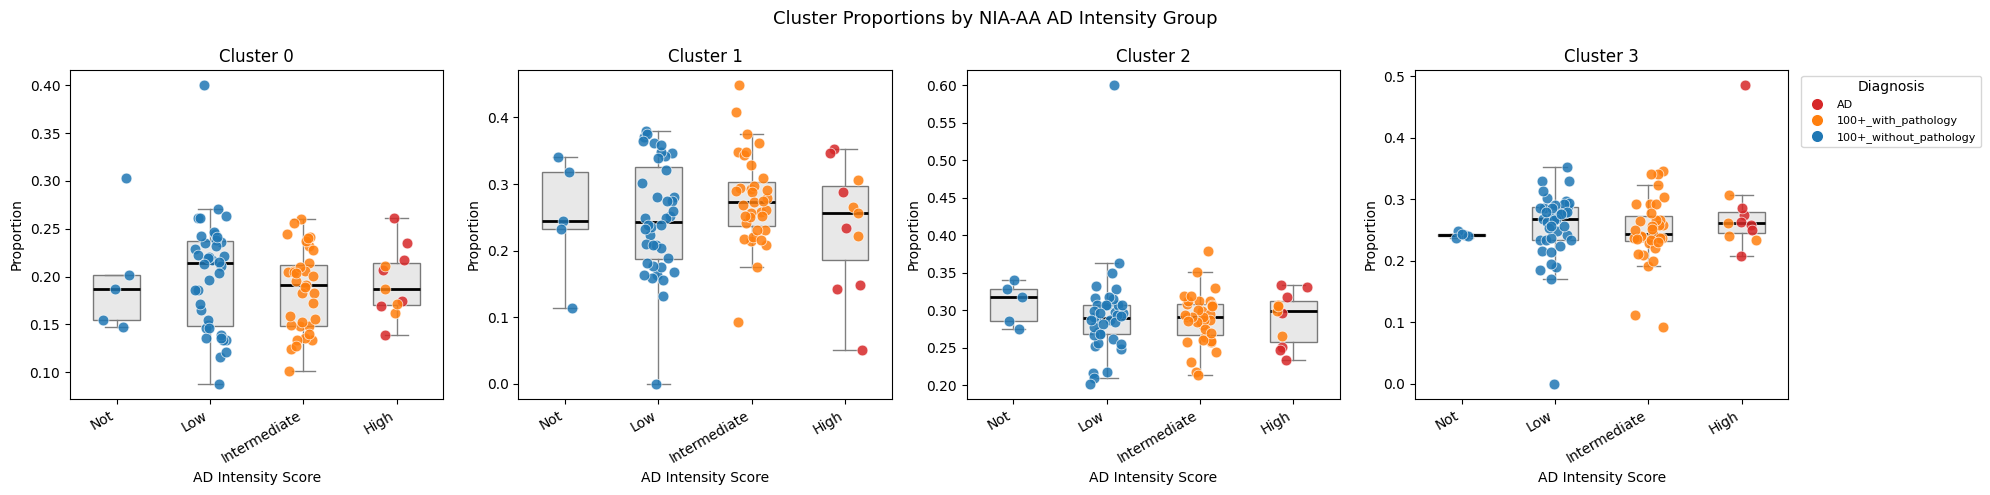

In [14]:
rng_jitter = np.random.default_rng(42)

df_plot = df_scan_full.dropna(subset=['AD_intensity_score']).drop_duplicates('scan_name').copy()

fig, axes = plt.subplots(1, len(hard_cols), figsize=(5 * len(hard_cols), 5), sharey=False)
if len(hard_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, hard_cols):
    for i, intensity in enumerate(AD_INTENSITY_ORDER):
        grp = df_plot[df_plot['AD_intensity_score'] == intensity]
        if grp.empty:
            continue
        ax.boxplot(
            grp[col].values, positions=[i], widths=0.5, showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor='lightgray', alpha=0.5),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color='gray'),
            capprops=dict(color='gray'),
        )
        jitter = rng_jitter.uniform(-0.18, 0.18, size=len(grp))
        for idx_j, (_, row) in enumerate(grp.iterrows()):
            color = DIAG_PALETTE.get(row['diagnosis_group_pathology'], 'gray')
            ax.scatter(i + jitter[idx_j], row[col], color=color, s=60,
                       alpha=0.85, zorder=5, edgecolors='white', linewidths=0.5)

    ax.set_xticks(range(len(AD_INTENSITY_ORDER)))
    ax.set_xticklabels(AD_INTENSITY_ORDER, rotation=30, ha='right')
    ax.set_xlabel('AD Intensity Score')
    ax.set_ylabel('Proportion')
    ax.set_title(col.replace('hard_cluster_', 'Cluster '))

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9, label=l)
           for l, c in DIAG_PALETTE.items()]
axes[-1].legend(handles=handles, title='Diagnosis', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.suptitle('Cluster Proportions by NIA-AA AD Intensity Group', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
from scipy.stats import kruskal, spearmanr

df_plot = df_scan_full.dropna(subset=['AD_intensity_score', 'AD_intensity_numeric']).drop_duplicates('scan_name')

rows = []
for col in hard_cols:
    groups = [
        df_plot.loc[df_plot['AD_intensity_score'] == g, col].dropna().values
        for g in AD_INTENSITY_ORDER
        if df_plot.loc[df_plot['AD_intensity_score'] == g, col].dropna().shape[0] > 0
    ]
    kw_stat, kw_p = kruskal(*groups) if len(groups) >= 2 else (np.nan, np.nan)

    valid = df_plot[['AD_intensity_numeric', col]].dropna()
    sp_r, sp_p = spearmanr(valid['AD_intensity_numeric'], valid[col]) if len(valid) > 2 else (np.nan, np.nan)

    rows.append({
        'Cluster': col.replace('hard_cluster_', 'Cluster '),
        'KW H': round(kw_stat, 3),
        'KW p': round(kw_p, 4),
        'Spearman r (trend)': round(sp_r, 3),
        'Spearman p (trend)': round(sp_p, 4),
        'N scans': len(valid),
    })

trend_stats_df = pd.DataFrame(rows)
print('=== Trend Test: Cluster Proportions vs AD Intensity Score ===')
display(trend_stats_df)

=== Trend Test: Cluster Proportions vs AD Intensity Score ===


,Cluster,KW H,KW p,Spearman r (trend),Spearman p (trend),N scans
0,Cluster 0,1.738,0.6285,-0.087,0.4110,91
1,Cluster 1,2.694,0.4412,0.079,0.4549,91
2,Cluster 2,2.014,0.5694,-0.029,0.7845,91
3,Cluster 3,2.935,0.4018,-0.015,0.8905,91


## Trend: Cluster Proportions by Individual A / B / C Scores

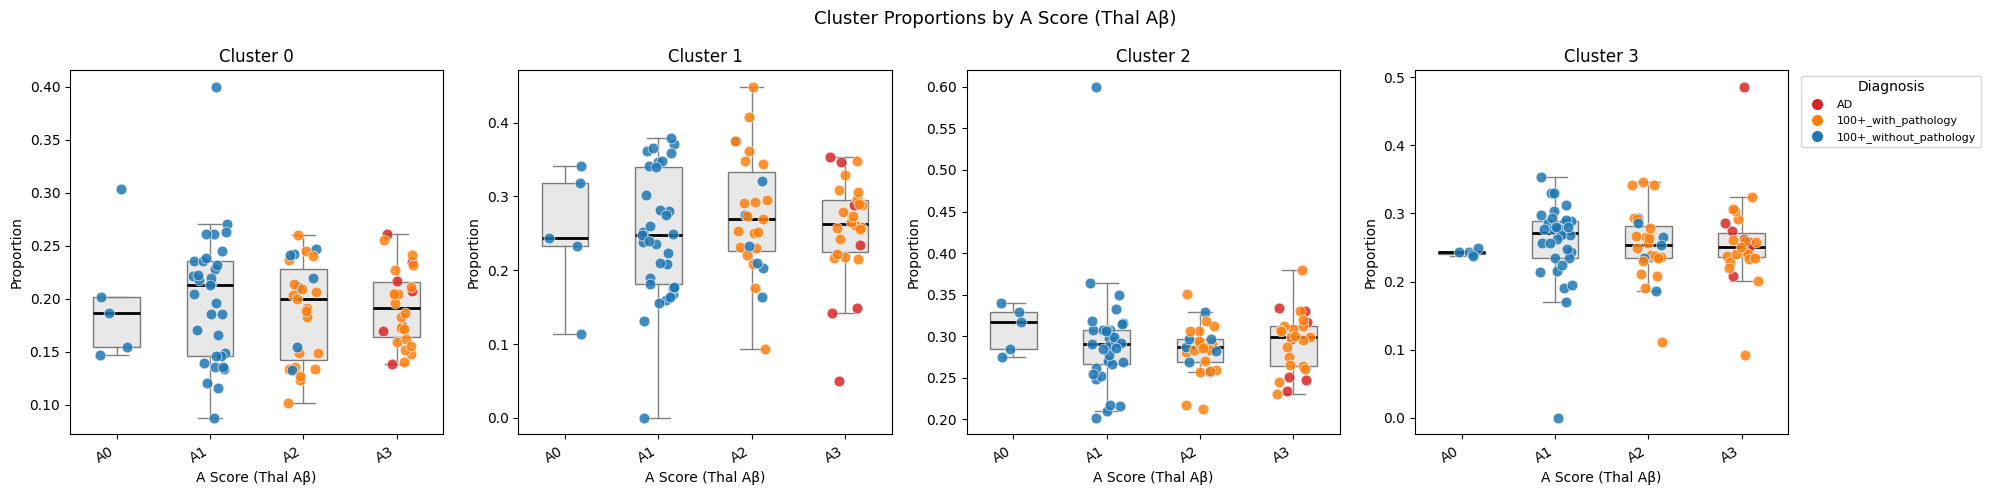

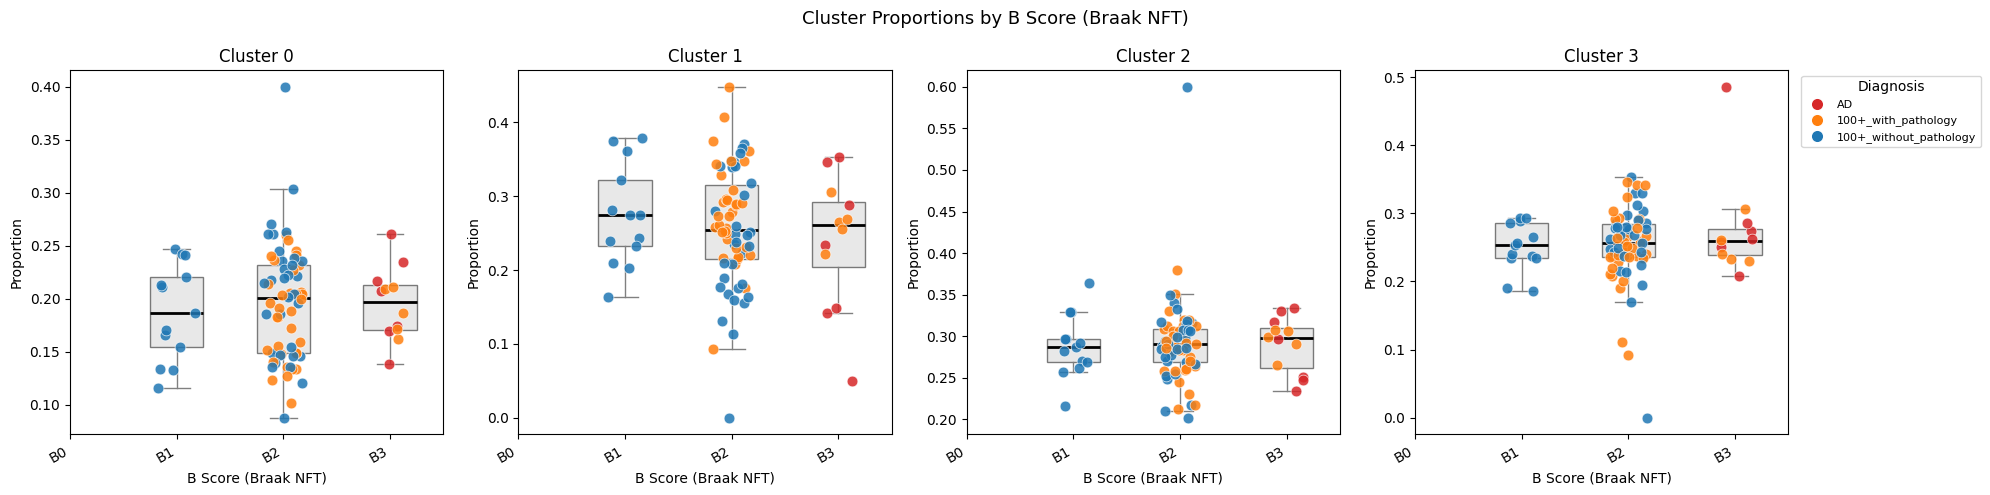

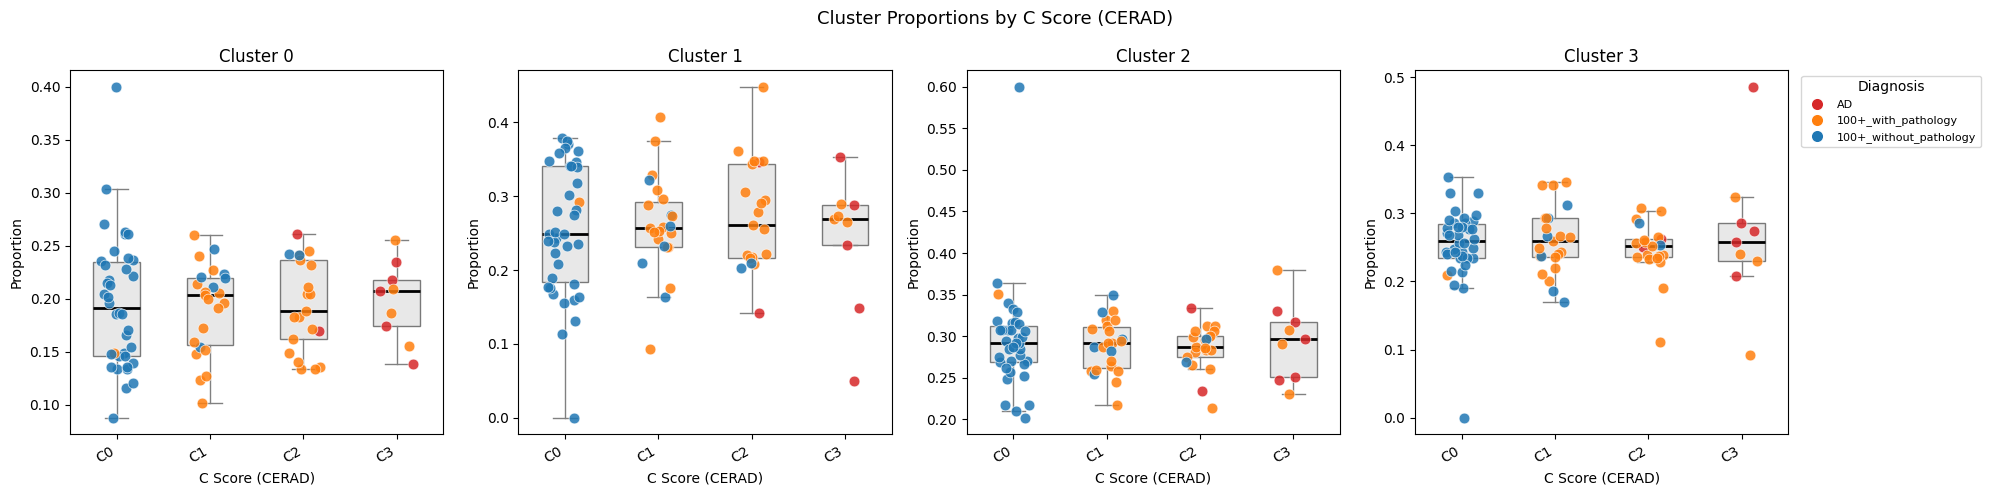

In [16]:
ABC_SCORES = [
    ('A_score', ['A0', 'A1', 'A2', 'A3'], 'A Score (Thal Aβ)'),
    ('B_score', ['B0', 'B1', 'B2', 'B3'], 'B Score (Braak NFT)'),
    ('C_score', ['C0', 'C1', 'C2', 'C3'], 'C Score (CERAD)'),
]

rng_jitter2 = np.random.default_rng(0)

for score_col, score_order, score_title in ABC_SCORES:
    df_plot = df_scan_full.dropna(subset=[score_col]).drop_duplicates('scan_name').copy()

    fig, axes = plt.subplots(1, len(hard_cols), figsize=(5 * len(hard_cols), 5), sharey=False)
    if len(hard_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, hard_cols):
        for i, level in enumerate(score_order):
            grp = df_plot[df_plot[score_col] == level]
            if grp.empty:
                continue
            ax.boxplot(
                grp[col].values, positions=[i], widths=0.5, showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor='lightgray', alpha=0.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color='gray'),
                capprops=dict(color='gray'),
            )
            jitter = rng_jitter2.uniform(-0.18, 0.18, size=len(grp))
            for idx_j, (_, row) in enumerate(grp.iterrows()):
                color = DIAG_PALETTE.get(row['diagnosis_group_pathology'], 'gray')
                ax.scatter(i + jitter[idx_j], row[col], color=color, s=60,
                           alpha=0.85, zorder=5, edgecolors='white', linewidths=0.5)

        ax.set_xticks(range(len(score_order)))
        ax.set_xticklabels(score_order, rotation=30, ha='right')
        ax.set_xlabel(score_title)
        ax.set_ylabel('Proportion')
        ax.set_title(col.replace('hard_cluster_', 'Cluster '))

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9, label=l)
               for l, c in DIAG_PALETTE.items()]
    axes[-1].legend(handles=handles, title='Diagnosis', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.suptitle(f'Cluster Proportions by {score_title}', fontsize=13)
    plt.tight_layout()
    plt.show()

## Scatter: Cluster Proportions vs Numeric AD Intensity Score

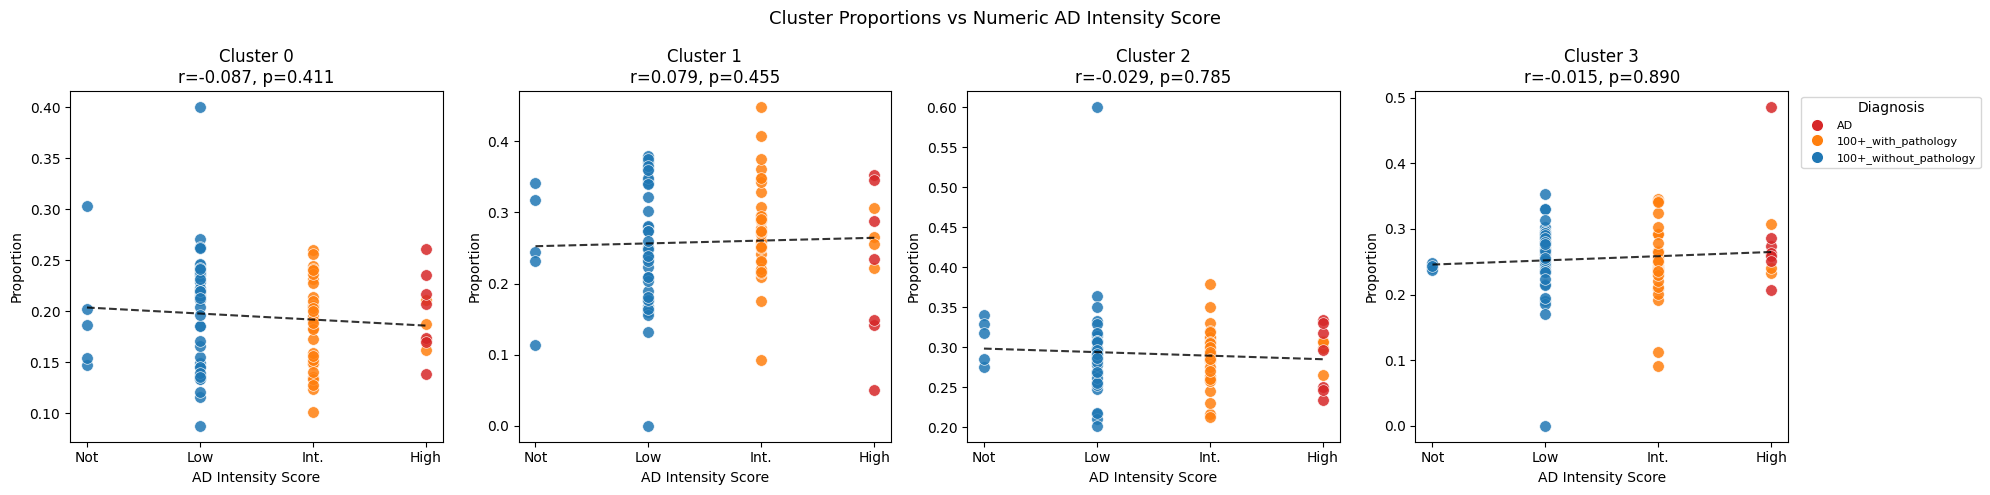

In [17]:
df_plot = df_scan_full.dropna(subset=['AD_intensity_numeric']).drop_duplicates('scan_name').copy()

fig, axes = plt.subplots(1, len(hard_cols), figsize=(5 * len(hard_cols), 5), sharey=False)
if len(hard_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, hard_cols):
    for diag_label, grp in df_plot.groupby('diagnosis_group_pathology'):
        color = DIAG_PALETTE.get(diag_label, 'gray')
        ax.scatter(grp['AD_intensity_numeric'], grp[col], color=color,
                   label=diag_label, alpha=0.85, s=70, edgecolors='white', linewidths=0.5)

    valid = df_plot[['AD_intensity_numeric', col]].dropna()
    if len(valid) > 2:
        x_v = valid['AD_intensity_numeric'].values.astype(float)
        y_v = valid[col].values.astype(float)
        slope, intercept, _, _, _ = stats.linregress(x_v, y_v)
        xfit = np.linspace(x_v.min(), x_v.max(), 100)
        ax.plot(xfit, intercept + slope * xfit, 'k--', linewidth=1.5, alpha=0.8)
        sp_r, sp_p = stats.spearmanr(x_v, y_v)
        stars = '***' if sp_p < 0.001 else '**' if sp_p < 0.01 else '*' if sp_p < 0.05 else ''
        ax.set_title(f"{col.replace('hard_cluster_', 'Cluster ')}\nr={sp_r:.3f}{stars}, p={sp_p:.3f}")
    else:
        ax.set_title(col.replace('hard_cluster_', 'Cluster '))

    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['Not', 'Low', 'Int.', 'High'])
    ax.set_xlabel('AD Intensity Score')
    ax.set_ylabel('Proportion')

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9, label=l)
           for l, c in DIAG_PALETTE.items()]
axes[-1].legend(handles=handles, title='Diagnosis', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.suptitle('Cluster Proportions vs Numeric AD Intensity Score', fontsize=13)
plt.tight_layout()
plt.show()

## Correlation: Cluster Proportions vs All Numeric Pathology Scores

In [18]:
df_corr_base = df_scan_full.drop_duplicates('scan_name').copy()
for c in hard_cols + pathology_numeric_cols:
    if c in df_corr_base.columns:
        df_corr_base[c] = pd.to_numeric(df_corr_base[c], errors='coerce')

corr_rows = []
for cl in hard_cols:
    for pc in pathology_numeric_cols:
        if pc not in df_corr_base.columns:
            continue
        valid = df_corr_base[[cl, pc]].dropna()
        if len(valid) > 2:
            r, p = stats.spearmanr(valid[cl], valid[pc])
        else:
            r, p = np.nan, np.nan
        corr_rows.append({
            'Cluster': cl.replace('hard_cluster_', 'Cluster '),
            'Pathology Score': DISPLAY_NAMES.get(pc, pc),
            'Spearman r': round(float(r), 3),
            'p-value': round(float(p), 4),
            'N': len(valid),
        })

corr_df = pd.DataFrame(corr_rows)
print('=== Spearman Correlations: Cluster Proportions vs Pathology Scores ===')
display(corr_df)

=== Spearman Correlations: Cluster Proportions vs Pathology Scores ===


,Cluster,Pathology Score,Spearman r,p-value,N
0,Cluster 0,AD Intensity,-0.087,0.4110,91
1,Cluster 0,A score (Thal),-0.036,0.7347,91
2,Cluster 0,B score (Braak),0.038,0.7233,91
3,Cluster 0,C score (CERAD),0.034,0.7493,91
4,Cluster 0,Braak NFT,0.094,0.3770,91
5,Cluster 0,CERAD,0.034,0.7493,91
6,Cluster 0,AT8 load,0.011,0.9212,90
7,Cluster 0,pTau217 load,0.077,0.4755,89
8,Cluster 0,GT38 load,0.133,0.2228,86
9,Cluster 1,AD Intensity,0.079,0.4549,91


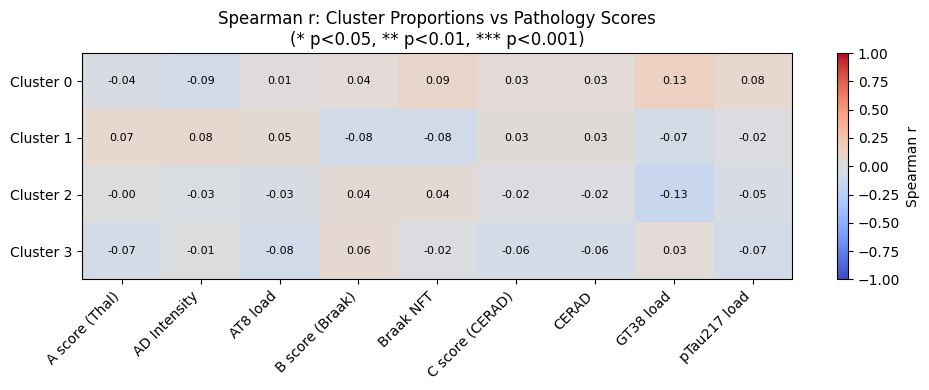

In [19]:
cluster_labels_display = [c.replace('hard_cluster_', 'Cluster ') for c in hard_cols]
patho_labels_display = [DISPLAY_NAMES.get(c, c) for c in pathology_numeric_cols if c in df_scan_full.columns]

corr_matrix = corr_df.pivot(index='Cluster', columns='Pathology Score', values='Spearman r')
corr_matrix = corr_matrix.reindex(index=cluster_labels_display)
pval_matrix = corr_df.pivot(index='Cluster', columns='Pathology Score', values='p-value')
pval_matrix = pval_matrix.reindex(index=cluster_labels_display)

fig, ax = plt.subplots(figsize=(max(8, len(patho_labels_display) * 1.1), max(4, len(cluster_labels_display) * 0.9)))
im = ax.imshow(corr_matrix.values.astype(float), cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Spearman r')

ax.set_xticks(range(corr_matrix.shape[1]))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(cluster_labels_display)))
ax.set_yticklabels(cluster_labels_display)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        r_val = corr_matrix.values[i, j]
        p_val = pval_matrix.values[i, j]
        if np.isnan(r_val):
            continue
        stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
        text_color = 'white' if abs(r_val) > 0.5 else 'black'
        ax.text(j, i, f'{r_val:.2f}{stars}', ha='center', va='center', fontsize=8, color=text_color)

ax.set_title('Spearman r: Cluster Proportions vs Pathology Scores\n(* p<0.05, ** p<0.01, *** p<0.001)')
plt.tight_layout()
plt.show()

## Scatter Grid: Each Cluster vs Each Pathology Score

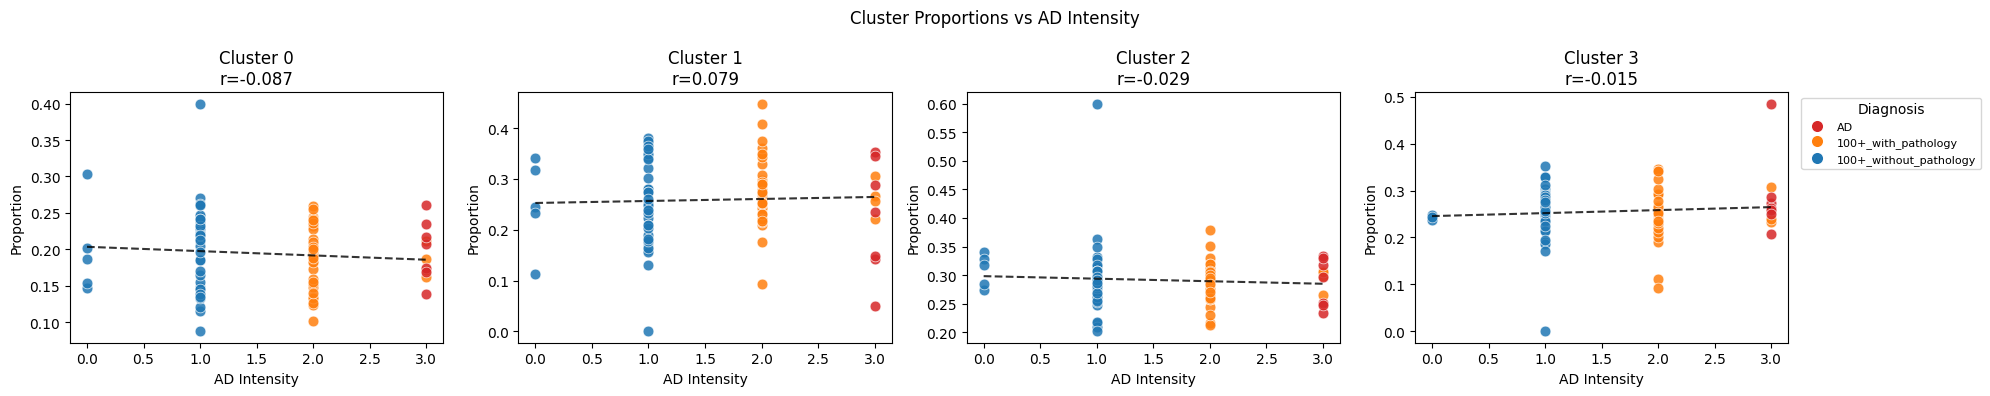

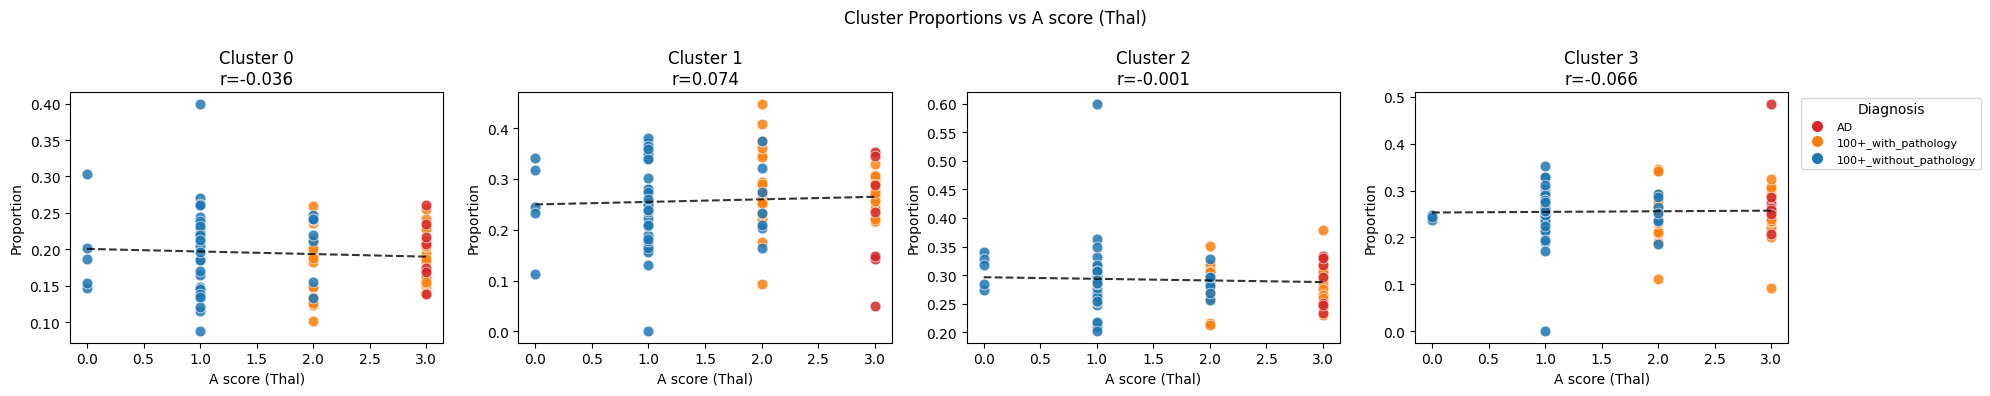

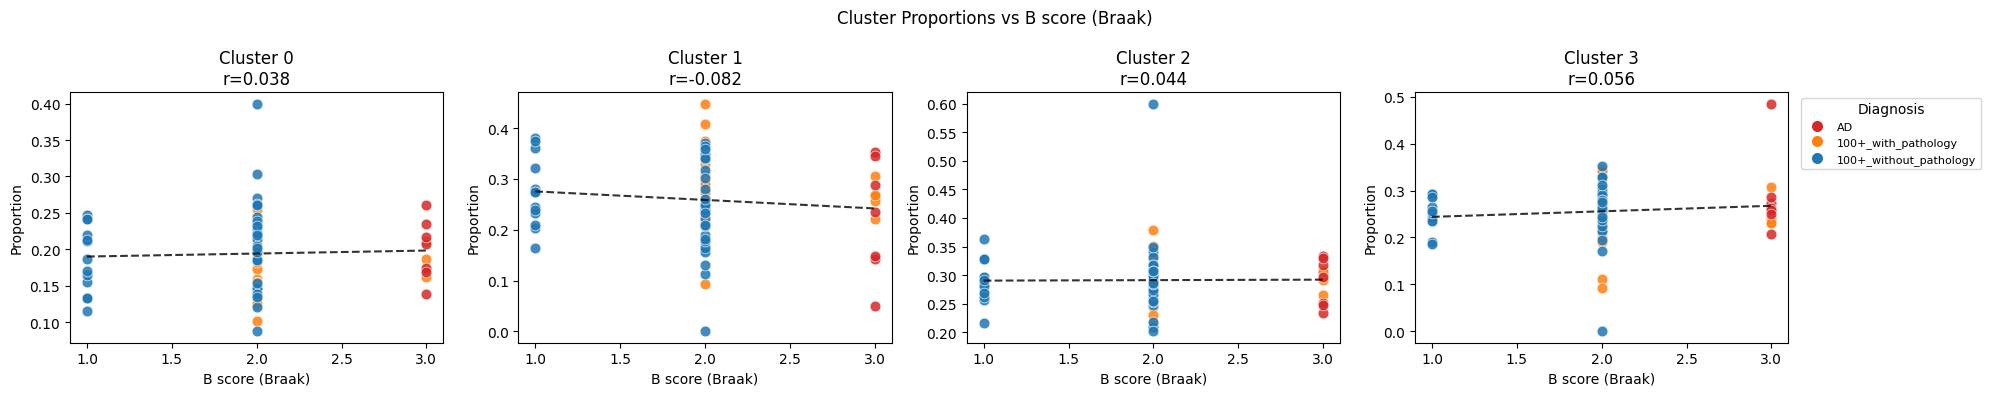

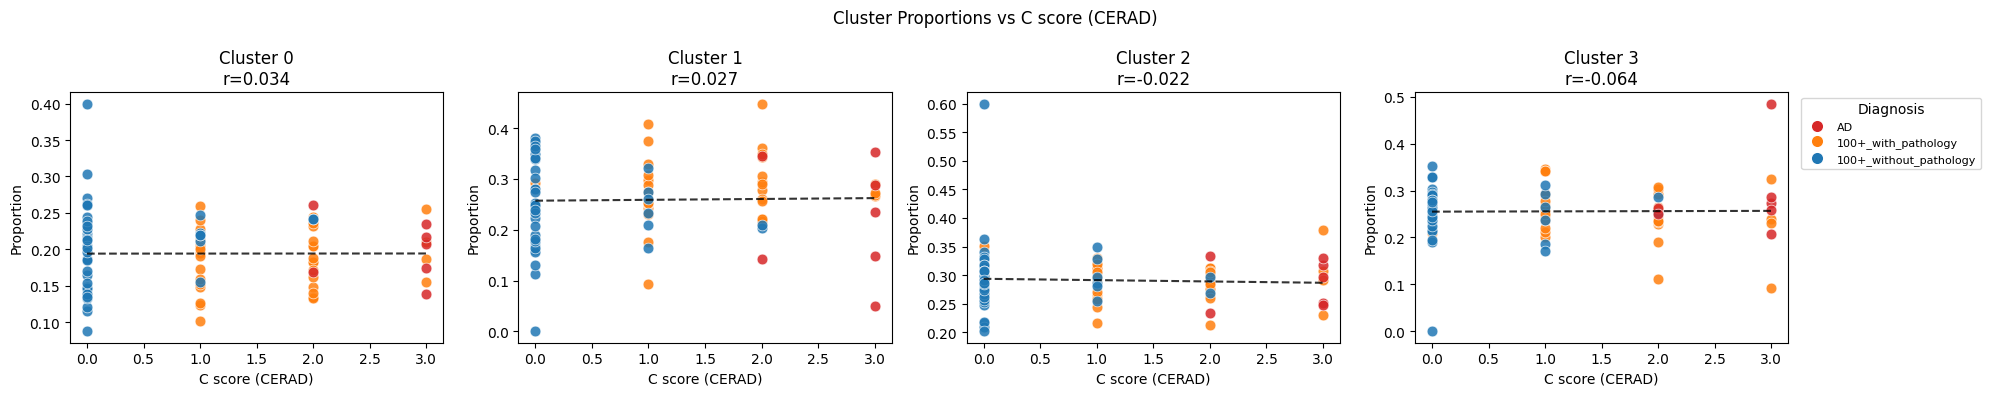

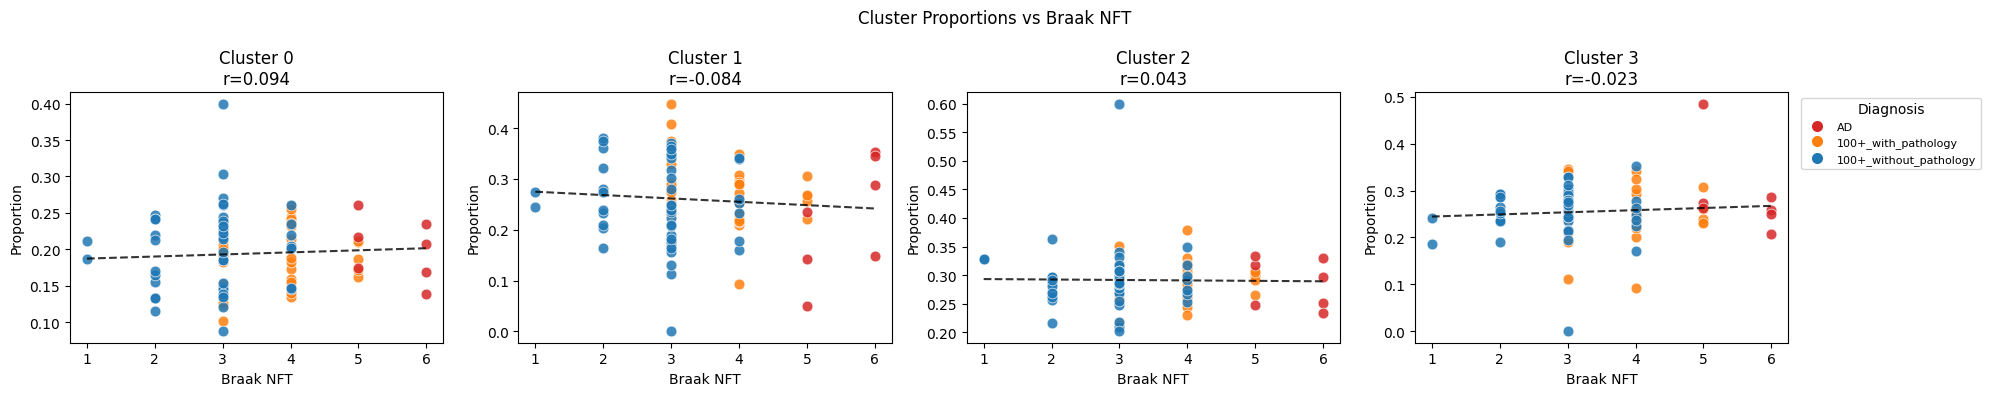

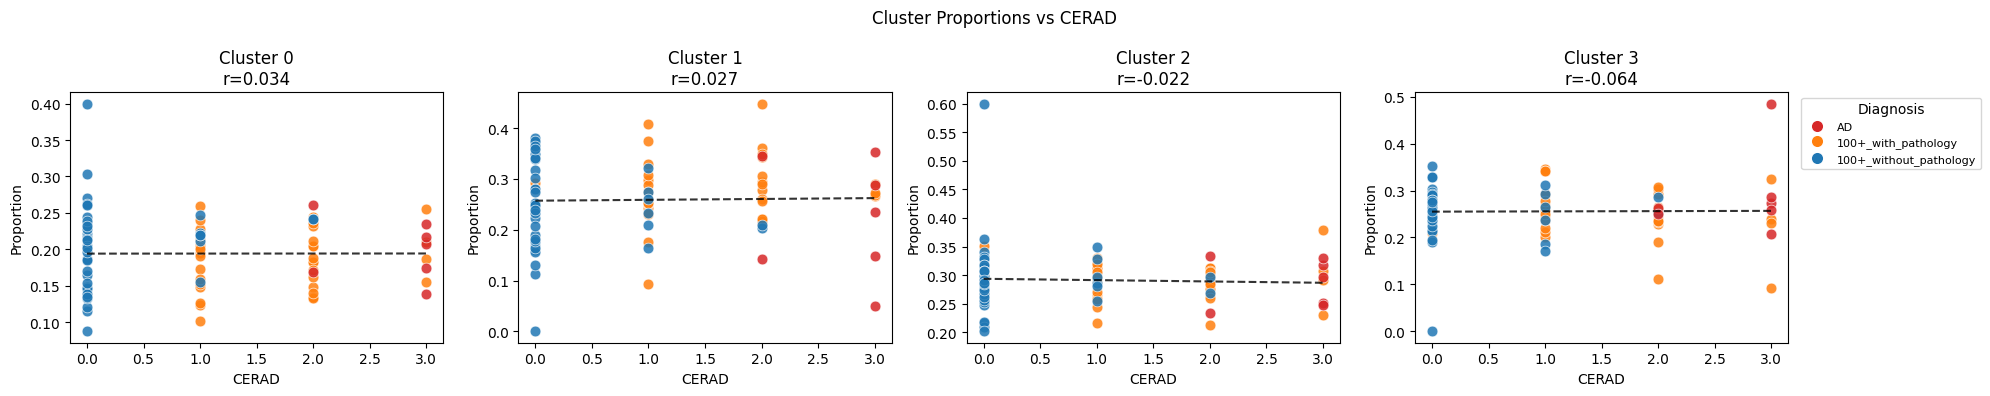

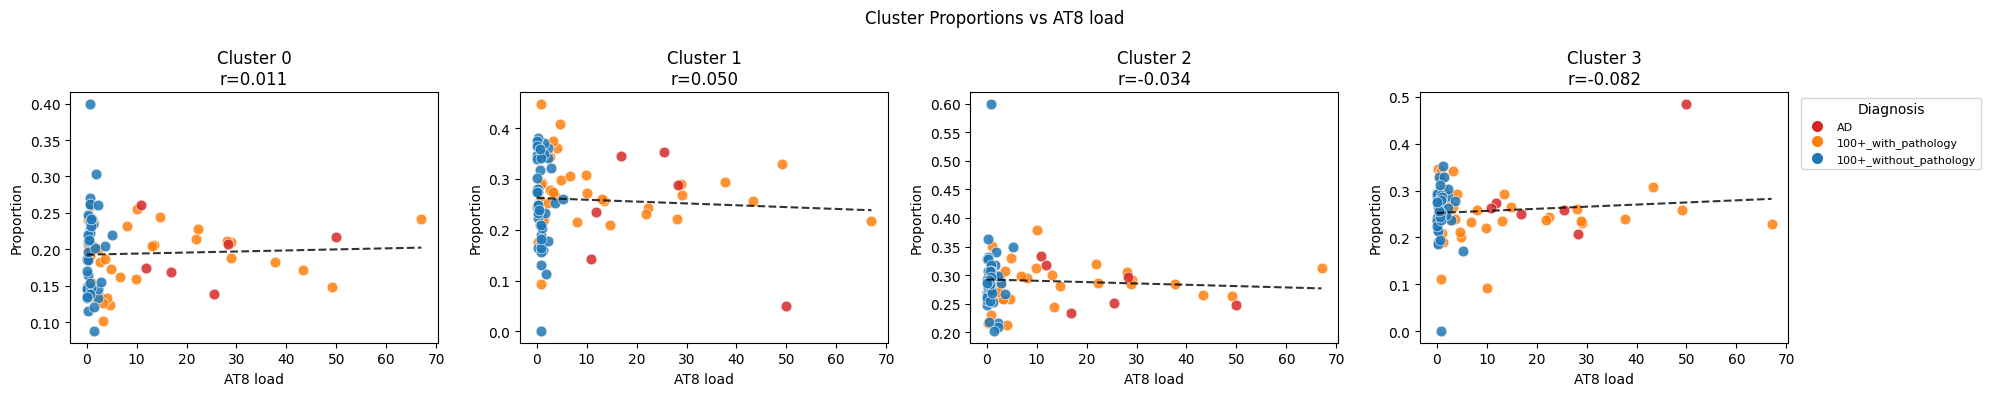

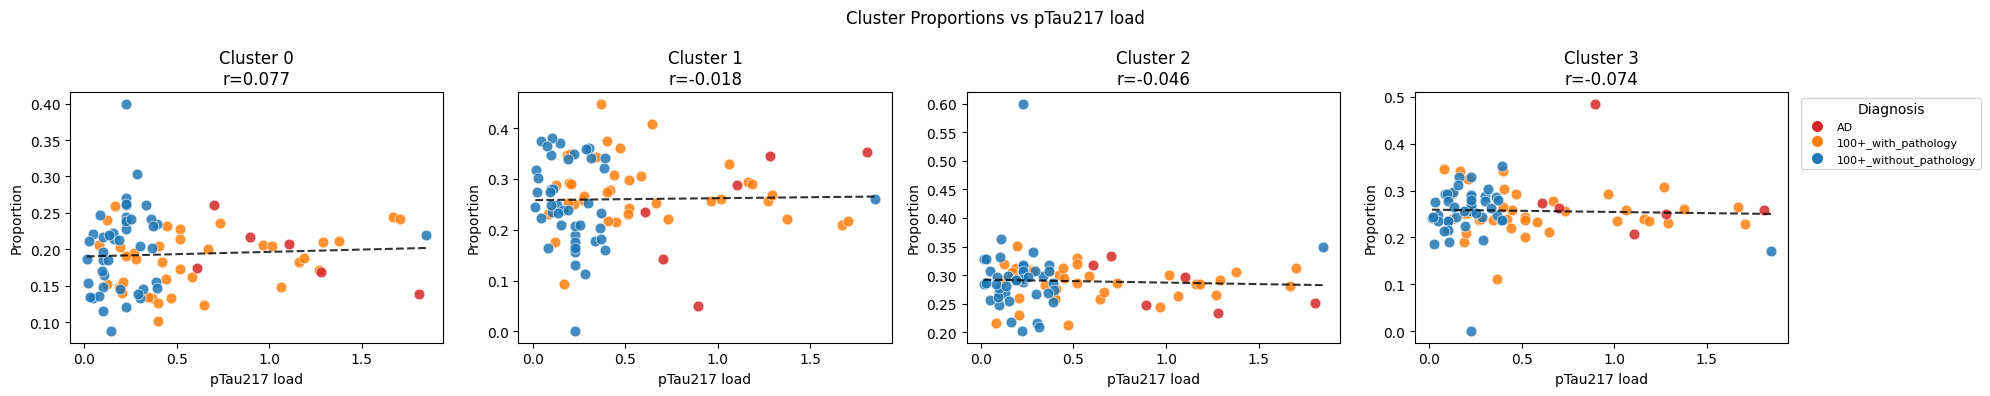

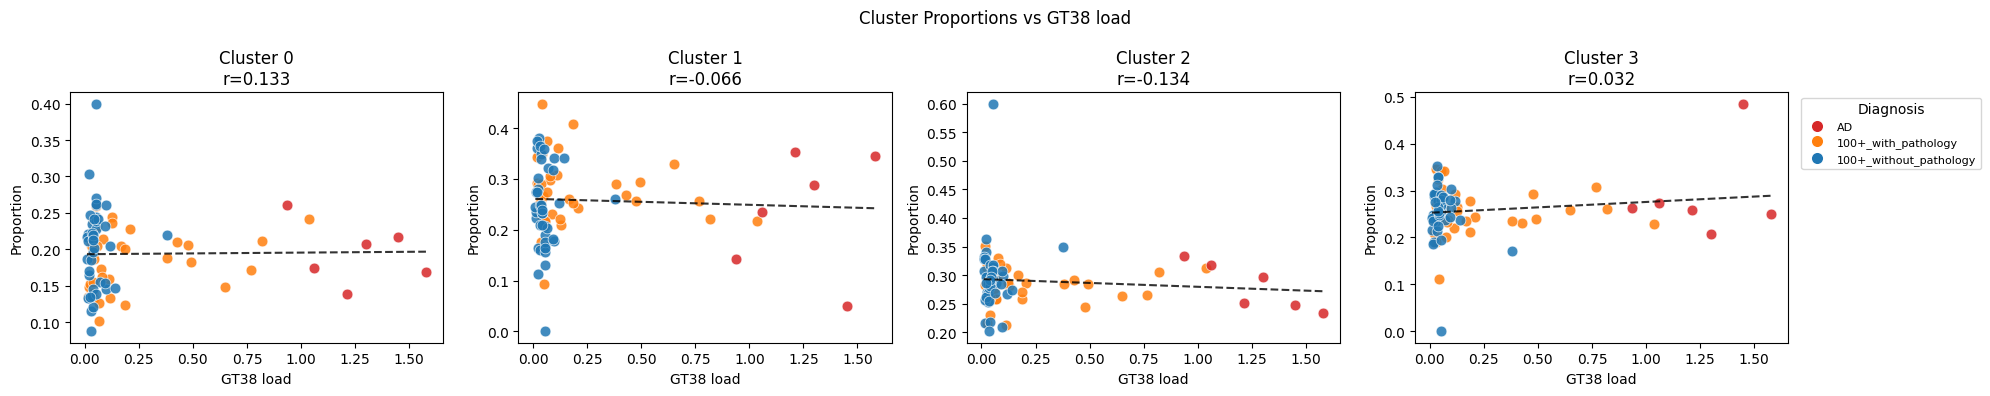

In [20]:
for pc in pathology_numeric_cols:
    if pc not in df_scan_full.columns:
        continue
    pc_display = DISPLAY_NAMES.get(pc, pc)

    df_plot = df_scan_full[hard_cols + [pc, 'diagnosis_group_pathology', 'scan_name']].drop_duplicates('scan_name').copy()
    df_plot[pc] = pd.to_numeric(df_plot[pc], errors='coerce')
    df_plot = df_plot.dropna(subset=[pc])
    if df_plot.empty:
        print(f'No data for {pc_display}, skipping.')
        continue

    fig, axes = plt.subplots(1, len(hard_cols), figsize=(5 * len(hard_cols), 4), sharey=False)
    if len(hard_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, hard_cols):
        for diag_label, grp in df_plot.groupby('diagnosis_group_pathology'):
            color = DIAG_PALETTE.get(diag_label, 'gray')
            ax.scatter(grp[pc], grp[col], color=color, label=diag_label,
                       alpha=0.85, s=60, edgecolors='white', linewidths=0.5)

        valid = df_plot[[pc, col]].dropna()
        if len(valid) > 2:
            x_v = valid[pc].values.astype(float)
            y_v = valid[col].values.astype(float)
            slope, intercept, _, _, _ = stats.linregress(x_v, y_v)
            xfit = np.linspace(x_v.min(), x_v.max(), 100)
            ax.plot(xfit, intercept + slope * xfit, 'k--', linewidth=1.5, alpha=0.8)
            sp_r, sp_p = stats.spearmanr(x_v, y_v)
            stars = '***' if sp_p < 0.001 else '**' if sp_p < 0.01 else '*' if sp_p < 0.05 else ''
            ax.set_title(f"{col.replace('hard_cluster_', 'Cluster ')}\nr={sp_r:.3f}{stars}")
        else:
            ax.set_title(col.replace('hard_cluster_', 'Cluster '))

        ax.set_xlabel(pc_display)
        ax.set_ylabel('Proportion')

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9, label=l)
               for l, c in DIAG_PALETTE.items()]
    axes[-1].legend(handles=handles, title='Diagnosis', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.suptitle(f'Cluster Proportions vs {pc_display}', fontsize=12)
    plt.tight_layout()
    plt.show()